<a href="https://www.kaggle.com/code/lalit7881/patient-readmission-dataset?scriptVersionId=301710496" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohamedasak/hospital-patient-readmission-dataset/hospital_readmission_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohamedasak/hospital-patient-readmission-dataset/hospital_readmission_dataset.csv")

In [3]:
df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [4]:
df.tail()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
7995,P07996,2022-01-11,Winter,95,Female,East,COPD,6,9,Interventional,11,6,2,Medicare,Skilled Nursing,0.97,1
7996,P07997,2022-05-05,Spring,63,Female,East,Kidney Disease,4,7,Surgical,7,4,1,Medicaid,Home Health,0.94,1
7997,P07998,2021-08-26,Summer,43,Female,East,Diabetes,3,6,Medical,4,2,3,Uninsured,Home Health,0.79,1
7998,P07999,2021-04-20,Spring,86,Male,West,Sepsis,7,12,Interventional,12,5,3,Medicare,Skilled Nursing,0.97,1
7999,P08000,2021-06-12,Summer,93,Female,North,Kidney Disease,7,8,Conservative,10,6,3,Medicare,Skilled Nursing,0.97,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [6]:
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


In [7]:
df.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

patient_id                    object
admission_date                object
season                        object
age                            int64
gender                        object
region                        object
primary_diagnosis             object
comorbidities_count            int64
length_of_stay                 int64
treatment_type                object
medications_count              int64
followup_visits_last_year      int64
prev_readmissions              int64
insurance_type                object
discharge_disposition         object
readmission_risk_score       float64
label                          int64
dtype: object

In [10]:
df.shape

(8000, 17)

In [11]:
df.nunique()

patient_id                   8000
admission_date               1092
season                          4
age                            78
gender                          2
region                          5
primary_diagnosis              11
comorbidities_count            10
length_of_stay                 13
treatment_type                  4
medications_count              17
followup_visits_last_year      11
prev_readmissions               6
insurance_type                  4
discharge_disposition           4
readmission_risk_score         85
label                           2
dtype: int64

In [12]:
df.columns

Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='object')

## EDA

In [13]:
# style
sns.set(style="whitegrid")

print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)


Dataset Shape: (8000, 17)

Columns: Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='object')


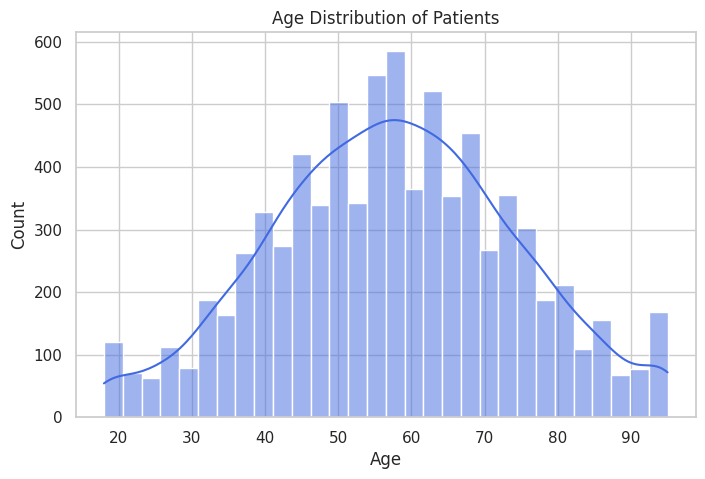

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, color='royalblue', kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

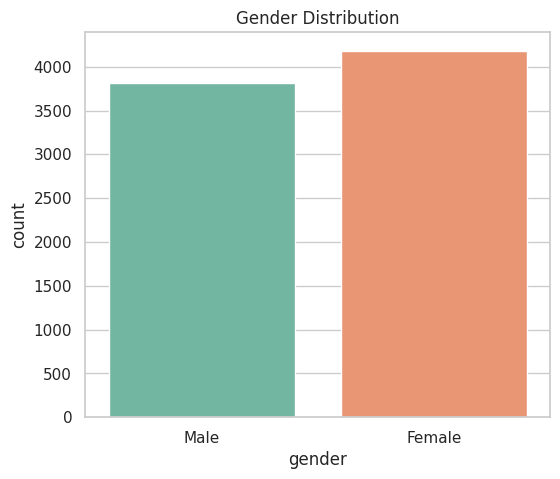

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Distribution")
plt.show()

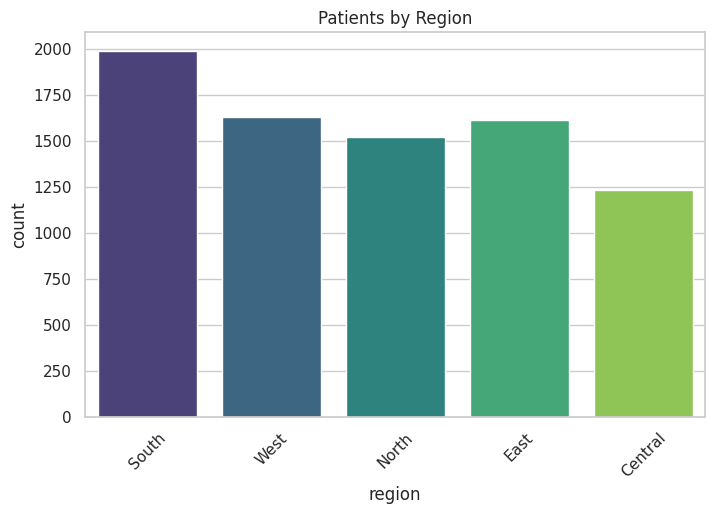

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='region', data=df, palette='viridis')
plt.title("Patients by Region")
plt.xticks(rotation=45)
plt.show()

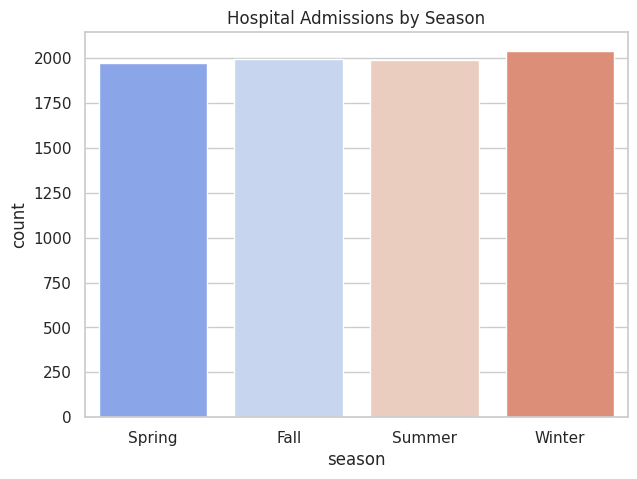

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(x='season', data=df, palette='coolwarm')
plt.title("Hospital Admissions by Season")
plt.show()


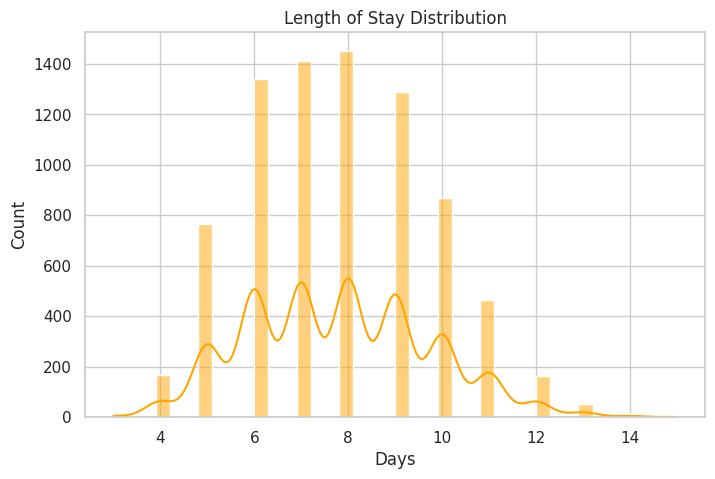

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['length_of_stay'], bins=40, color='orange', kde=True)
plt.title("Length of Stay Distribution")
plt.xlabel("Days")
plt.show()


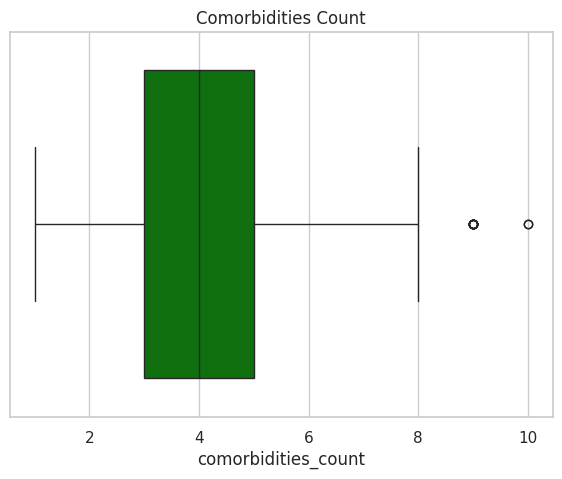

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x='comorbidities_count', data=df, color='green')
plt.title("Comorbidities Count")
plt.show()

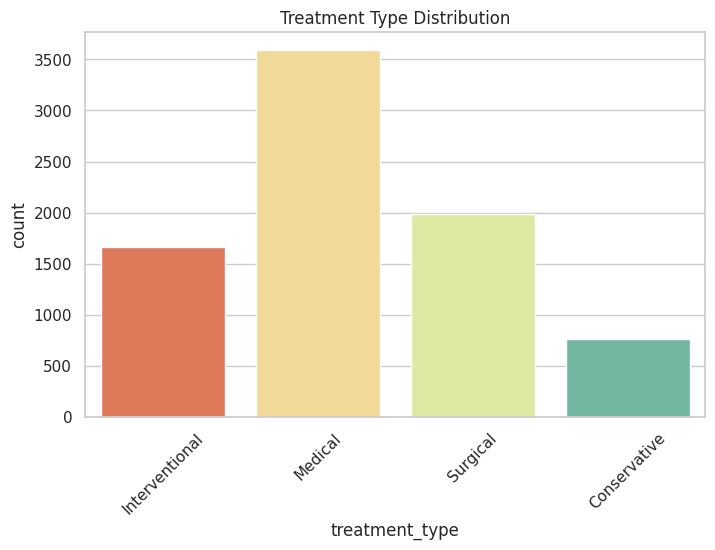

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='treatment_type', data=df, palette='Spectral')
plt.title("Treatment Type Distribution")
plt.xticks(rotation=45)
plt.show()

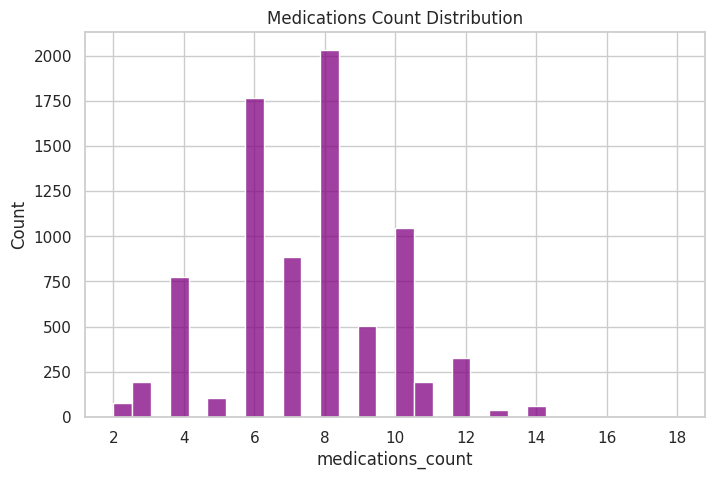

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['medications_count'], bins=30, color='purple')
plt.title("Medications Count Distribution")
plt.show()

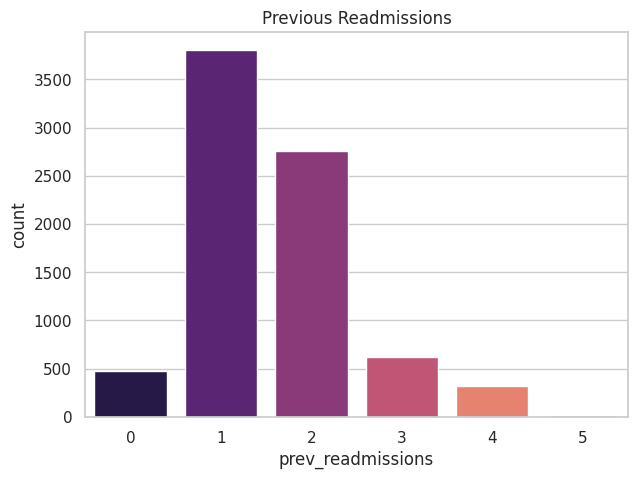

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x='prev_readmissions', data=df, palette='magma')
plt.title("Previous Readmissions")
plt.show()

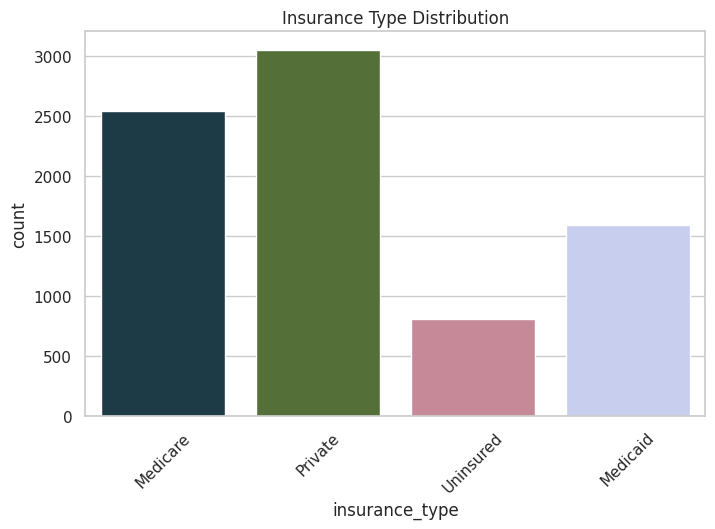

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x='insurance_type', data=df, palette='cubehelix')
plt.title("Insurance Type Distribution")
plt.xticks(rotation=45)
plt.show()

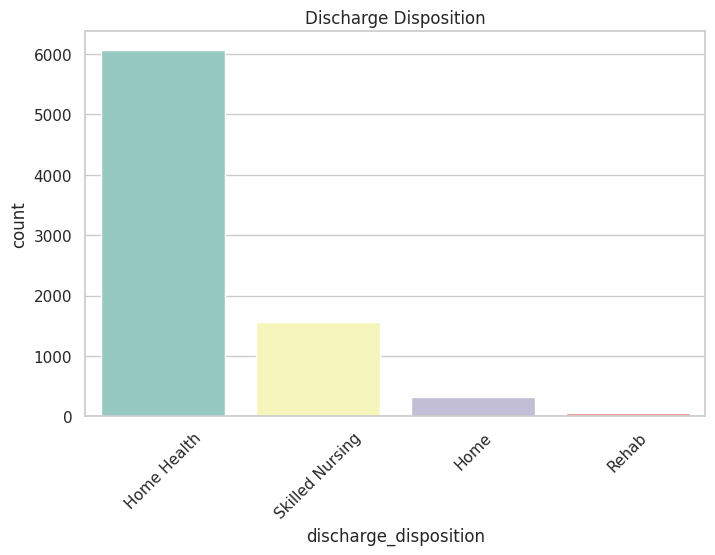

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='discharge_disposition', data=df, palette='Set3')
plt.title("Discharge Disposition")
plt.xticks(rotation=45)
plt.show()

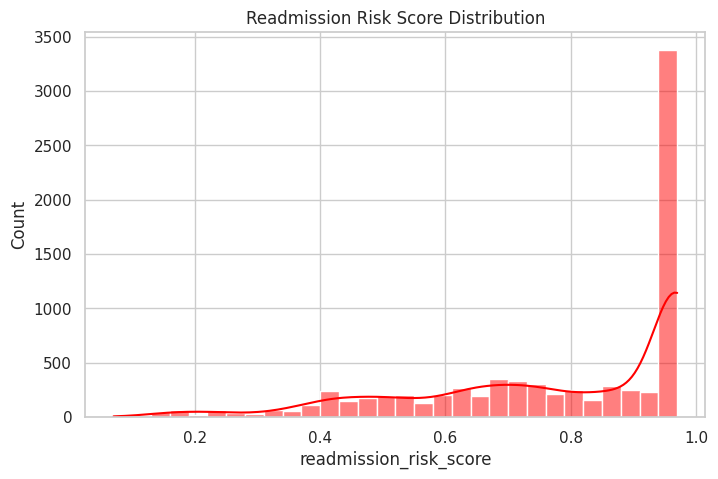

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['readmission_risk_score'], bins=30, color='red', kde=True)
plt.title("Readmission Risk Score Distribution")
plt.show()

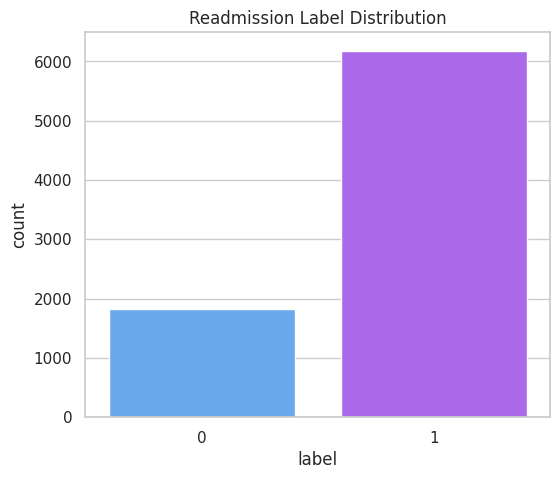

In [26]:
plt.figure(figsize=(6,5))
sns.countplot(x='label', data=df, palette='cool')
plt.title("Readmission Label Distribution")
plt.show()

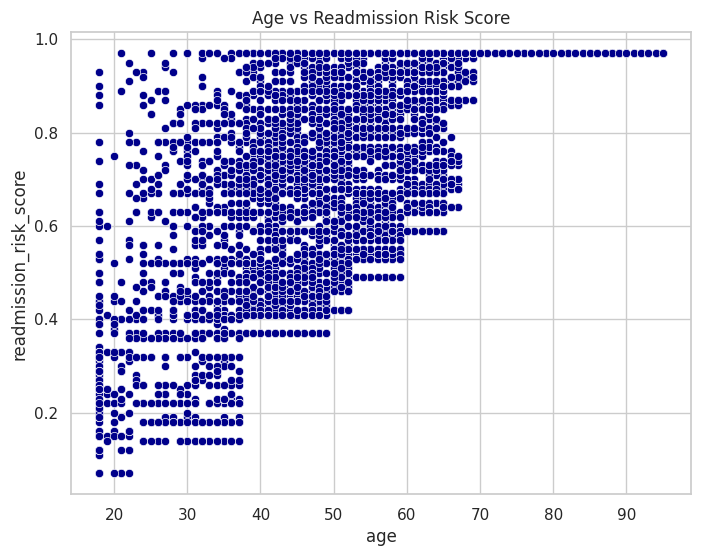

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='readmission_risk_score', data=df, color='darkblue')
plt.title("Age vs Readmission Risk Score")
plt.show()

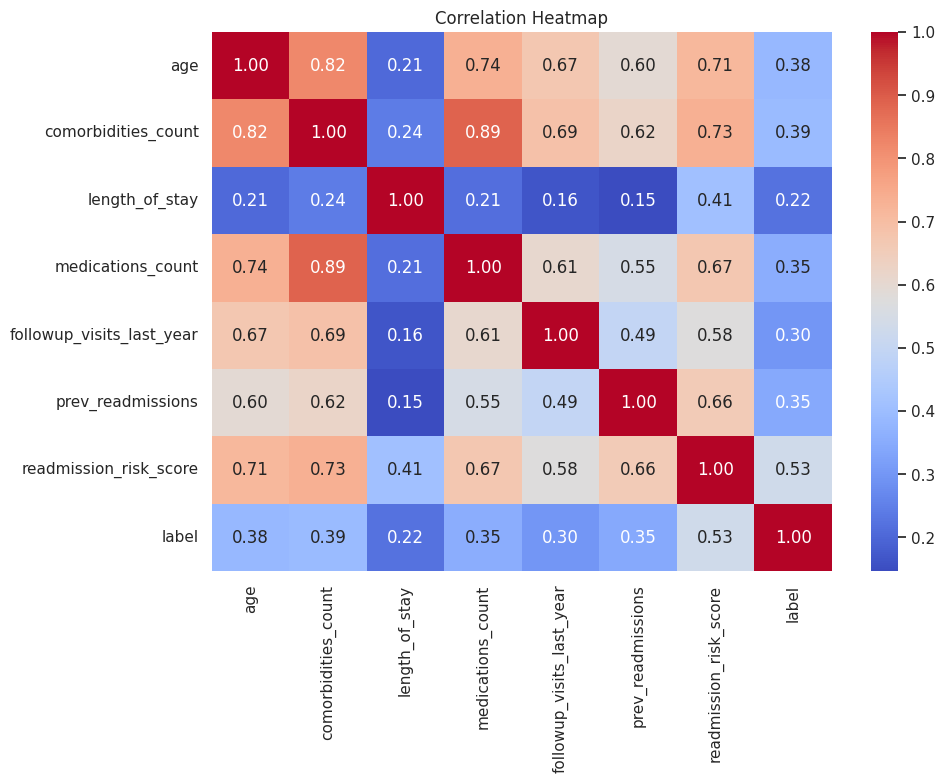

In [28]:
plt.figure(figsize=(10,7))

numeric_cols = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Feature engineering

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

In [30]:
df = df.copy()

# remove patient id
df = df.drop(columns=['patient_id'])

# convert admission_date
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['admission_year'] = df['admission_date'].dt.year
df['admission_month'] = df['admission_date'].dt.month

df = df.drop(columns=['admission_date'])

In [31]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [32]:
X = df.drop('label', axis=1)
y = df['label']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (6400, 16)
Testing Size: (1600, 16)


In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "SVM": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

In [36]:
results = {}

for name, model in models.items():

    print("\n" + "="*60)
    print("MODEL:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100

    print("Accuracy:", round(acc,2), "%")

    results[name] = acc

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))


MODEL: Logistic Regression
Accuracy: 81.62 %

Classification Report
              precision    recall  f1-score   support

           0       0.61      0.45      0.52       351
           1       0.86      0.92      0.89      1249

    accuracy                           0.82      1600
   macro avg       0.73      0.68      0.70      1600
weighted avg       0.80      0.82      0.81      1600


MODEL: Decision Tree
Accuracy: 75.06 %

Classification Report
              precision    recall  f1-score   support

           0       0.44      0.47      0.45       351
           1       0.85      0.83      0.84      1249

    accuracy                           0.75      1600
   macro avg       0.64      0.65      0.65      1600
weighted avg       0.76      0.75      0.75      1600


MODEL: Random Forest
Accuracy: 80.75 %

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.46      0.51       351
           1       0.86      0.90      0.8

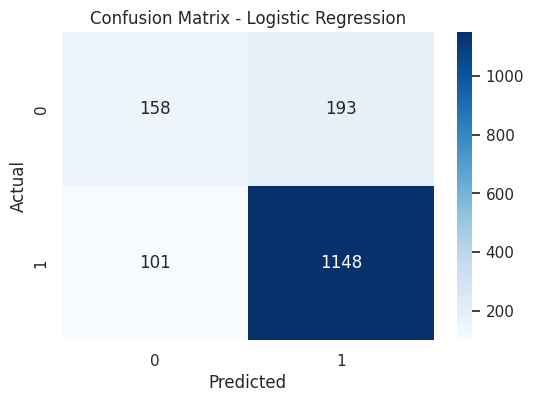

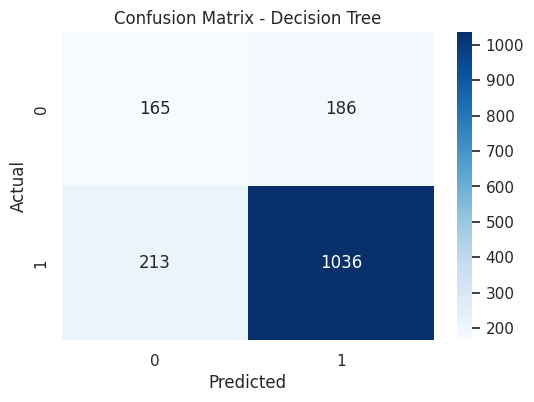

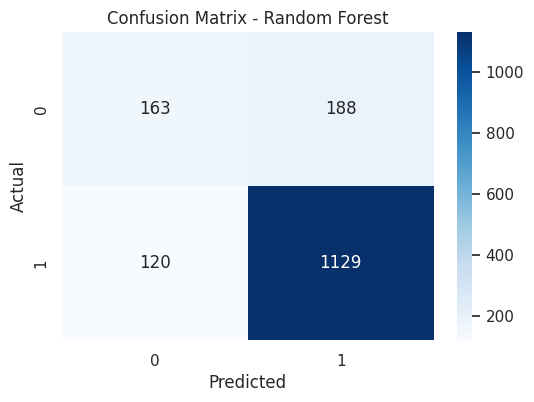

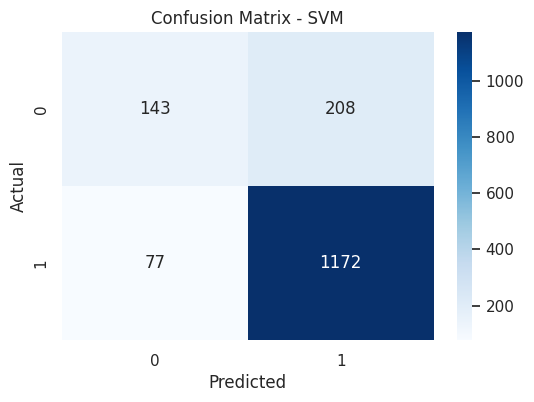

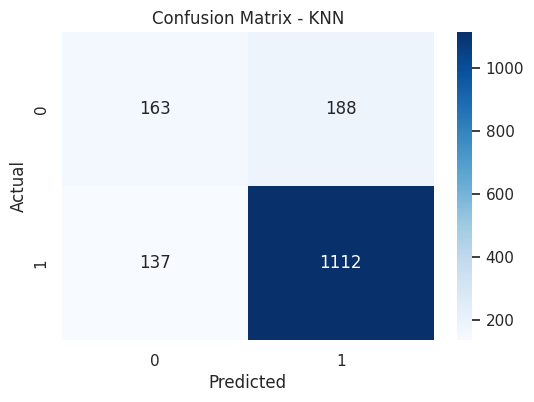

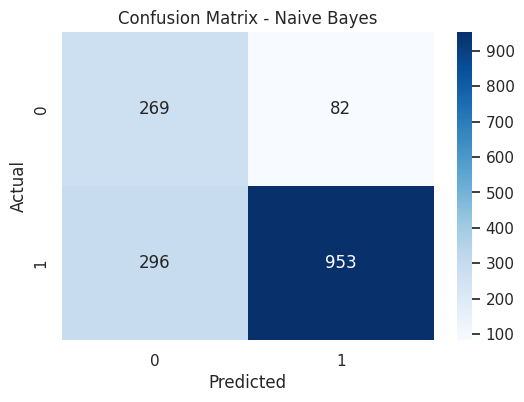

In [37]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

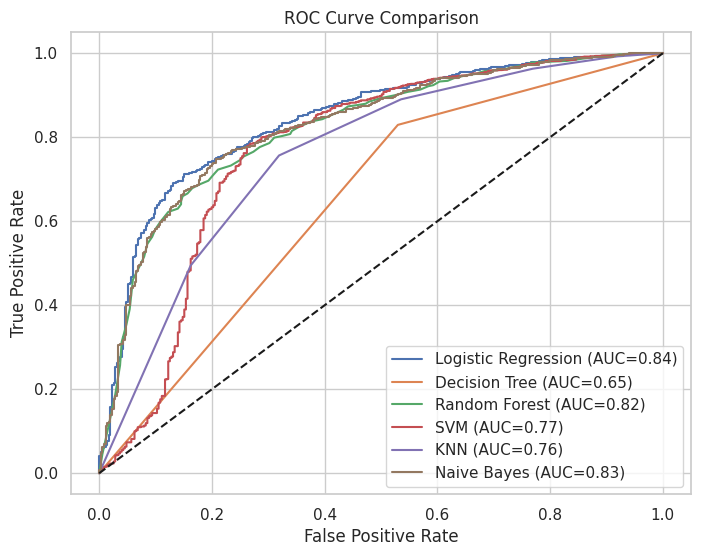

In [38]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

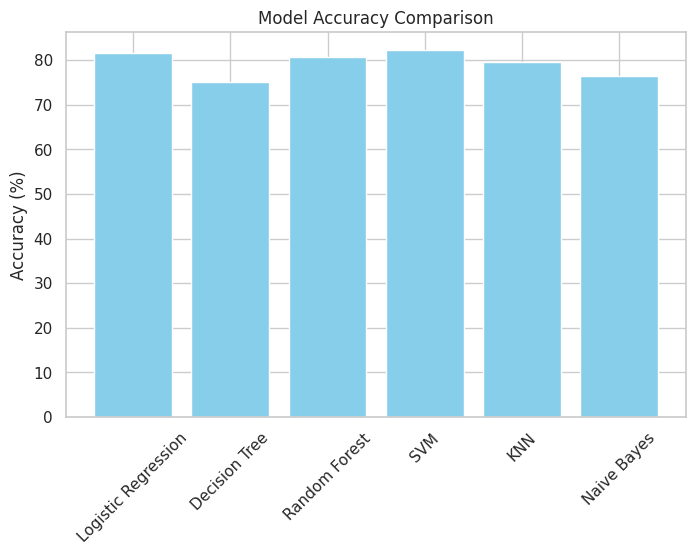

In [39]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies, color='skyblue')

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.xticks(rotation=45)

plt.show()

## Thank you..pls upvote!!!!!!